In [1]:
import sys
from pathlib import Path
root = Path.cwd()
while not (root / "Models").is_dir():
    root = root.parent
sys.path.insert(0, str(root))

from config import *

from Models.Papers.Liu2025 import Liu2025

z1 paper ndens=81.9 1 / deg2, sum of n 82.01 1 / deg2, int of dndz 82.01 1 / deg2
z2 paper ndens=148.1 1 / deg2, sum of n 148.18 1 / deg2, int of dndz 148.18 1 / deg2
z3 paper ndens=162.4 1 / deg2, sum of n 162.52 1 / deg2, int of dndz 162.52 1 / deg2
z4 paper ndens=148.3 1 / deg2, sum of n 148.50 1 / deg2, int of dndz 148.50 1 / deg2


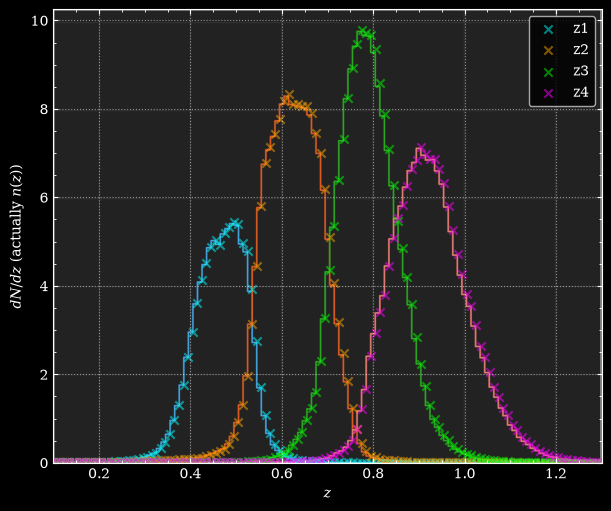

In [4]:
importlib.reload(Liu2025)
fig, ax = Liu2025.Fig2().full()

from Models import TargetData

for zbin, color in zip(['z1', 'z2', 'z3', 'z4'], ['cyan', 'orange', 'lime', 'magenta']):
    L25 = TargetData.Liu2025(zbin=zbin)
    L25.make_zdist()
    print(f'{L25.zbin} paper ndens={L25.nGal}, sum of n {np.sum(L25.n_z):.2f}, int of dndz {np.trapezoid(L25.dndz, L25.z):.2f}')
    ax.scatter(L25.z, L25.n_z, alpha=0.5, marker='x', c=color, label=f'{L25.zbin}')

ax.legend()
plt.show()

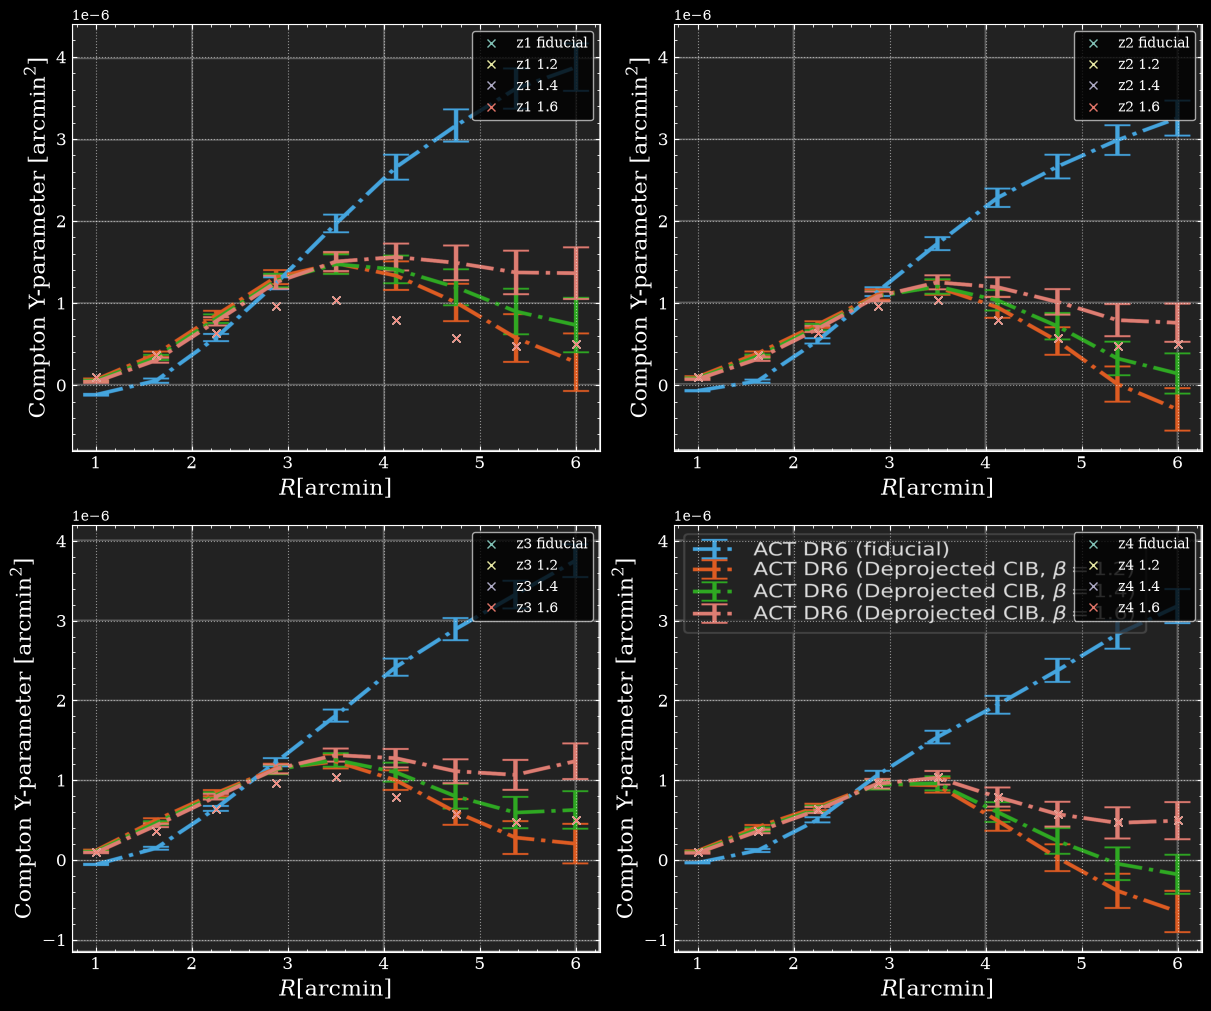

In [12]:
importlib.reload(Liu2025)
fig, axs = Liu2025.Fig3().full()

from Models import Measurements

for zbin, ax in zip(['z1', 'z2', 'z3', 'z4'], axs.flatten()):
    for beta in Measurements.Liu2025.subs['Beta']:
        L25 = Measurements.Liu2025({'zbin':zbin, 'Beta':beta, 'ACTDR':'DR6', 'dp':'beta', 'TCIB':'10.7'})
        ax.errorbar(L25.R, L25.tSZ_data, L25.tSZ_err, lw=0,alpha=0.9,marker='x', label=f'{zbin} {beta}')
    ax.legend()
plt.show()

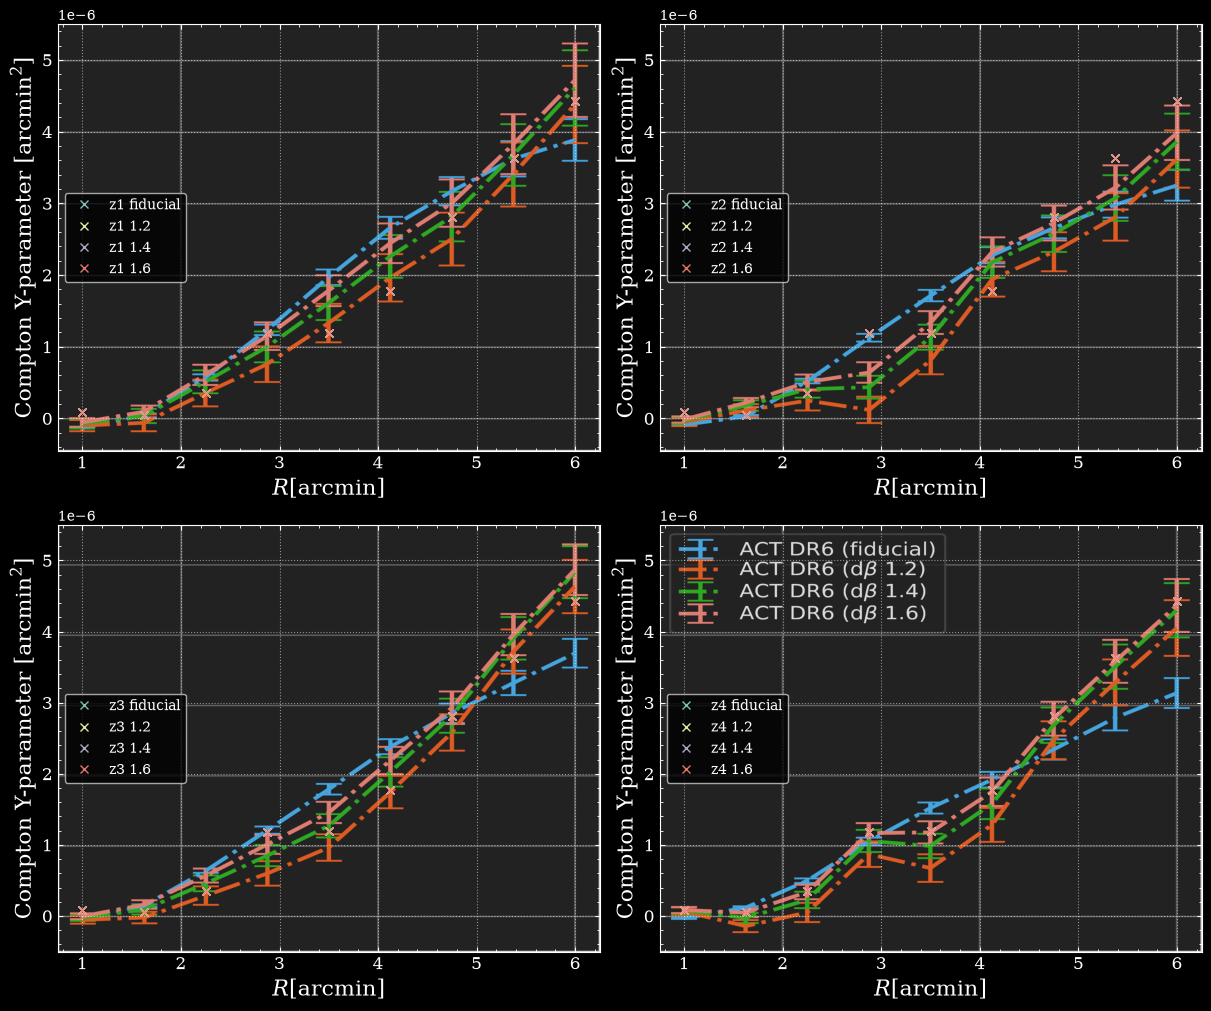

In [14]:
importlib.reload(Liu2025)
fig, axs = Liu2025.Fig4().full()

from Models import Measurements

for zbin, ax in zip(['z1', 'z2', 'z3', 'z4'], axs.flatten()):
    for beta in Measurements.Liu2025.subs['Beta']:
        L25 = Measurements.Liu2025({'zbin':zbin, 'Beta':beta, 'ACTDR':'DR6', 'dp':'dBeta', 'TCIB':'10.7'})
        ax.errorbar(L25.R, L25.tSZ_data, L25.tSZ_err, lw=0,alpha=0.9,marker='x', label=f'{zbin} {beta}')
    ax.legend(loc='center left')
plt.show()